### Convolution, Images, and What We’ll See First

This notebook introduces 2D convolution using familiar images. We’ll start by loading a color photo and turning it into grayscale, then quickly inspect how image data is represented in memory.

- **What the next code cell does**:
  - Shows the original RGB image next to its grayscale version.
  - Prints array **shape**, **dtype**, and **min/max** so you can see typical encodings:
    - **RGB uint8**: shape `(H, W, 3)`, values `0–255` per channel.
    - **RGB float**: same shape, values `0–1` per channel.
    - **Grayscale float**: shape `(H, W)`, values `0–1`.
  - Demonstrates **RGBA** by adding an alpha (transparency) gradient and compositing over a checkerboard.
  - Plots simple **histograms** for RGB and grayscale to visualize value ranges.

These quick visuals set the stage for understanding how convolutional filters operate over pixel neighborhoods to detect edges, blur, sharpen, and more.

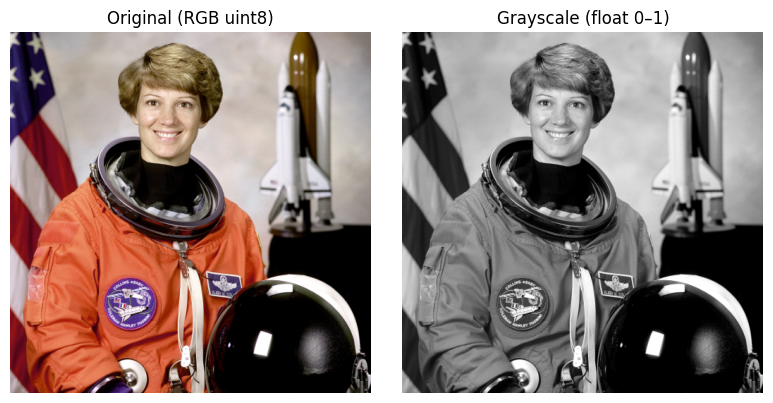

original_uint8 (RGB): shape=(512, 512, 3), dtype=uint8, min=0.000000, max=255.000000
original_float (RGB): shape=(512, 512, 3), dtype=float64, min=0.000000, max=1.000000
grayscale_float: shape=(512, 512), dtype=float64, min=0.000000, max=1.000000


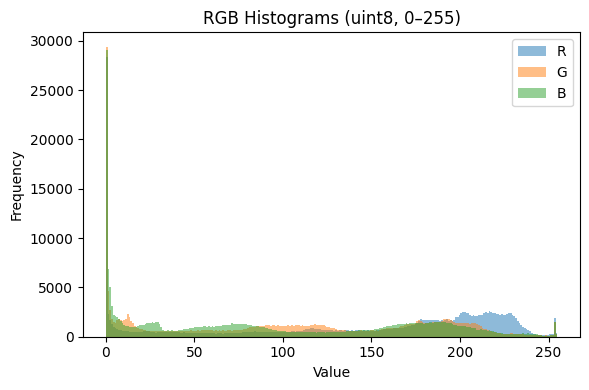

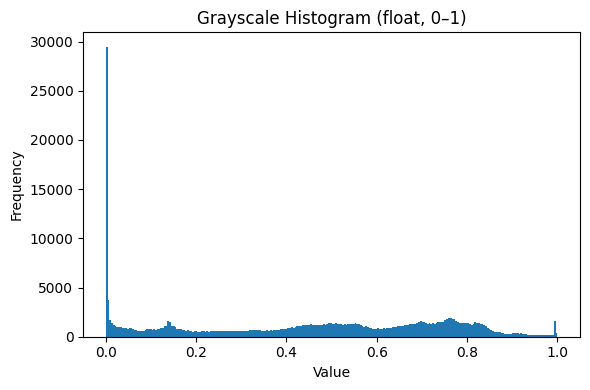

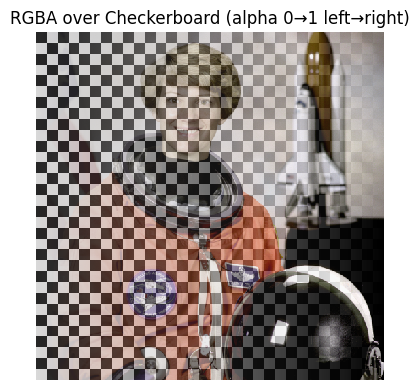

In [7]:
# Let's expand the user's snippet to:
# 1) Show the original + grayscale images
# 2) Print array shapes/dtypes and min/max to explain encoding
# 3) Plot histograms for RGB and grayscale ranges (0..255 for uint8, 0..1 for float)
# 4) Demonstrate an RGBA image with a left→right alpha gradient over a checkerboard background

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.color import rgb2gray

# ------------- Load and convert -------------
original_uint8 = data.astronaut()              # RGB uint8, shape (H, W, 3), range 0..255 per channel
grayscale_float = rgb2gray(original_uint8)     # float64 grayscale, shape (H, W), range 0..1
original_float = img_as_float(original_uint8)  # float64 RGB, range 0..1 per channel

# ------------- Show original + grayscale side-by-side (images, not charts) -------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_uint8)
axes[0].set_title("Original (RGB uint8)")
axes[0].axis("off")

axes[1].imshow(grayscale_float, cmap=plt.cm.gray, vmin=0, vmax=1)
axes[1].set_title("Grayscale (float 0–1)")
axes[1].axis("off")

fig.tight_layout()
plt.show()

# ------------- Print encoding details -------------
def describe(arr, name):
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
          f"min={arr.min():.6f}, max={arr.max():.6f}")

describe(original_uint8,  "original_uint8 (RGB)")
describe(original_float,  "original_float (RGB)")
describe(grayscale_float, "grayscale_float")

# ------------- Charts: RGB and grayscale histograms (each chart in its own figure) -------------
# RGB histogram (uint8, 0..255)
fig = plt.figure(figsize=(6, 4))
# Flatten channels
r, g, b = original_uint8[..., 0].ravel(), original_uint8[..., 1].ravel(), original_uint8[..., 2].ravel()
# Plot with default colors; no explicit colors set
plt.hist(r, bins=256, alpha=0.5, label="R")
plt.hist(g, bins=256, alpha=0.5, label="G")
plt.hist(b, bins=256, alpha=0.5, label="B")
plt.title("RGB Histograms (uint8, 0–255)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Grayscale histogram (float, 0..1)
fig = plt.figure(figsize=(6, 4))
plt.hist(grayscale_float.ravel(), bins=256)
plt.title("Grayscale Histogram (float, 0–1)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------- RGBA demo: add an alpha gradient and composite over a checkerboard -------------
H, W = original_float.shape[:2]
# Alpha gradient from 0 (fully transparent) to 1 (fully opaque) left->right
alpha = np.tile(np.linspace(0.0, 1.0, W, dtype=np.float64), (H, 1))
rgba = np.dstack([original_float, alpha])  # (H, W, 4)

# Checkerboard background
tile = 16
yy, xx = np.indices((H, W))
checker = ((yy // tile + xx // tile) % 2).astype(float) * 0.7 + 0.15  # values ~[0.15, 0.85]
checker_rgb = np.dstack([checker, checker, checker])

# Show background then overlay RGBA foreground (images, not charts)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.imshow(checker_rgb, interpolation="nearest")
ax.imshow(rgba, interpolation="nearest")  # respects embedded alpha channel
ax.set_title("RGBA over Checkerboard (alpha 0→1 left→right)")
ax.axis("off")
plt.tight_layout()
plt.show()


### Convolution with a 3×3 Kernel: Why and Where It’s Used

Convolution takes a small grid of weights (a "kernel") and scans it across an image, producing a new image that emphasizes patterns the kernel is designed to detect.

- **Why it matters**:
  - **Edge/texture detection**: Highlight boundaries, lines, and corners used in computer vision and graphics.
  - **Noise reduction & smoothing**: Blur or denoise with averaging/Gaussian kernels.
  - **Feature extraction for ML/CNNs**: Early CNN layers use small kernels (often 3×3) to learn edges and textures; deeper layers compose these into higher‑level features.
  - **Image enhancement**: Sharpen, emboss, or stylize by reweighting local neighborhoods.

- **Where it’s used**:
  - Classical vision (OpenCV, SciPy), computational photography, medical imaging, remote sensing.
  - Deep learning (ConvNets) for classification, detection, segmentation, generative models, and more.

- **How it works (at each pixel)**:
  1) Take a local 3×3 patch from the image.
  2) Multiply element‑wise by the kernel and sum the 9 products (a dot product).
  3) Write the sum to the output at the patch’s center position.

Below we apply a classic edge detector and visualize:
- Original image
- Convolved (edge‑enhanced) image
- The 3×3 kernel heatmap with its values

Sample location (y=256, x=256)
3x3 patch:
 [[0.05934431 0.04841294 0.0240651 ]
 [0.1229     0.05708941 0.05851098]
 [0.14337882 0.08033608 0.06158431]]
Kernel:
 [[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]
Elementwise product:
 [[-0.05934431 -0.04841294 -0.0240651 ]
 [-0.1229      0.45671529 -0.05851098]
 [-0.14337882 -0.08033608 -0.06158431]]
Sum of products (conv result at center) = -0.14181725490196076
Check with convolve2d output = -0.1418172549019608


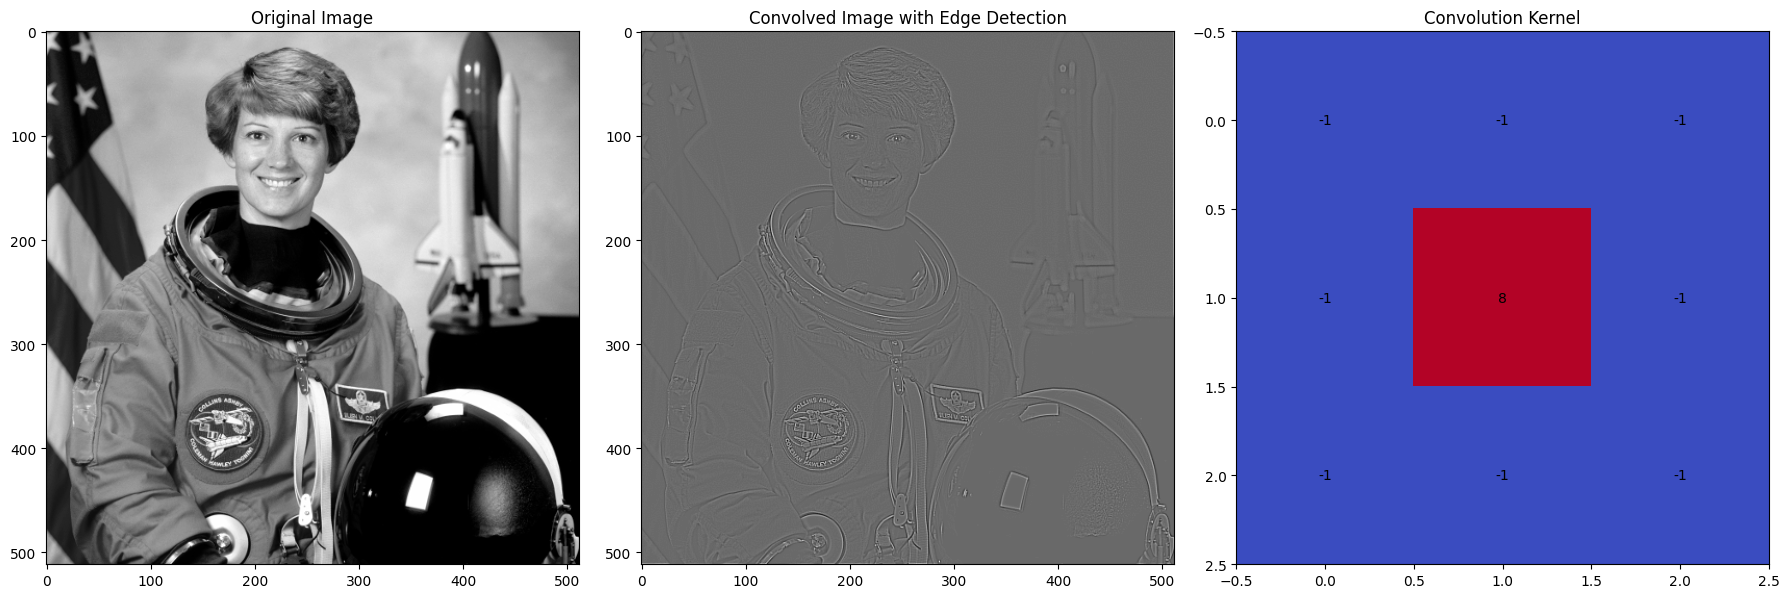

In [8]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from PIL import Image

# Define a simple edge detection filter
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

# Apply the 2D convolution
convolved_image = convolve2d(img_array, kernel, mode='same')

# ---- Small numeric example: one 3x3 patch and its convolution result ----
H, W = img_array.shape[:2]
cy, cx = H // 2, W // 2  # pick a safe center location
patch = img_array[cy-1:cy+2, cx-1:cx+2].astype(np.float64)
weighted = patch * kernel
result = float(weighted.sum())
print(f"Sample location (y={cy}, x={cx})")
print("3x3 patch:\n", patch)
print("Kernel:\n", kernel)
print("Elementwise product:\n", weighted)
print("Sum of products (conv result at center) =", result)
print("Check with convolve2d output =", convolved_image[cy, cx])

# Plot original image, convolved image, and kernel
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Increase the number of subplots to 3

# Plot original image
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")

# Plot convolved image
axes[1].imshow(convolved_image, cmap='gray')
axes[1].set_title("Convolved Image with Edge Detection")

# Plot kernel visualization
kernel_img = axes[2].imshow(kernel, cmap='coolwarm', interpolation='none')
axes[2].set_title("Convolution Kernel")
# Annotate the kernel values on the plot
for i in range(kernel.shape[0]):
    for j in range(kernel.shape[1]):
        axes[2].text(j, i, str(kernel[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


### Understanding Stride in Convolution

In this cell, we will explore how changing the **stride** affects the output of convolution. The **stride** controls how much we move the kernel over the image:

- **Stride 1**: The kernel moves one pixel at a time. This results in a detailed output, as the convolution examines every possible position.
- **Stride 2 (or higher)**: The kernel skips some pixels, which leads to a smaller output image and faster computation. This is known as **downsampling**. The resulting image is less detailed but faster to compute.

The function below applies convolution with a given stride and compares the results.


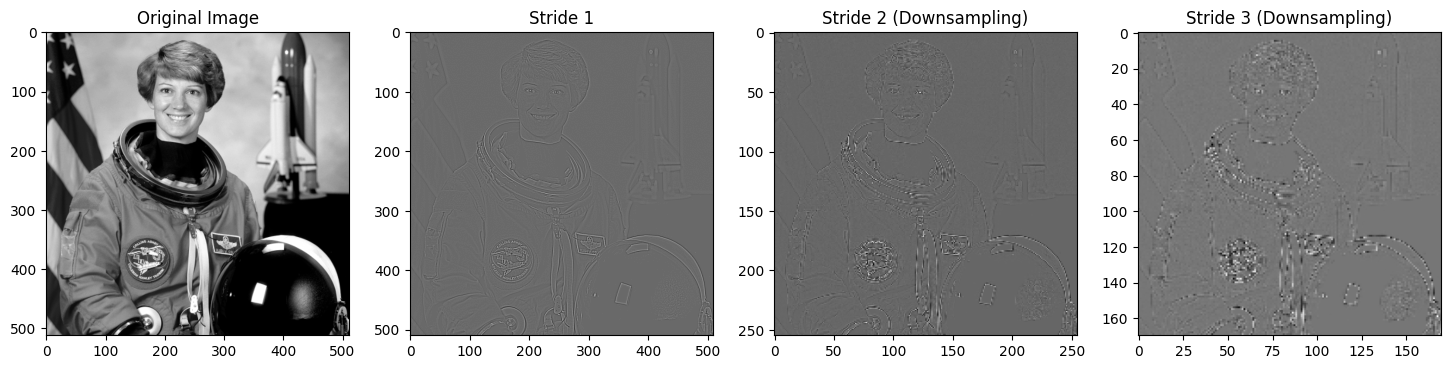

In [9]:
# Function to demonstrate stride
def convolve_with_stride(image, kernel, stride):
    output = convolve2d(image, kernel, mode='valid')[::stride, ::stride]
    return output

# Stride 1 vs Stride 2 convolution
stride_1 = convolve_with_stride(img_array, kernel, stride=1)
stride_2 = convolve_with_stride(img_array, kernel, stride=2)
stride_3 = convolve_with_stride(img_array, kernel, stride=3)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(stride_1, cmap='gray')
axes[1].set_title("Stride 1")
axes[2].imshow(stride_2, cmap='gray')
axes[2].set_title("Stride 2 (Downsampling)")
axes[3].imshow(stride_3, cmap='gray')
axes[3].set_title("Stride 3 (Downsampling)")
plt.show()


### Max Pooling: Simplifying the Image

In this step, we will explore **max pooling**, a technique used in neural networks to reduce the size of an image while preserving important features.

#### What is Max Pooling?
Max pooling divides the image into small regions (here, 2x2 blocks) and keeps only the largest value from each block. This reduces the resolution of the image but keeps the most important information. It's like summarizing an area by its strongest feature.

#### Why Use Max Pooling?
1. **Downsampling**: Reduces the size of the data, making the network faster and less prone to overfitting.
2. **Feature Preservation**: Even with reduced resolution, important features (like edges) remain in the image.

In the code below, we apply a **2x2 max pooling** operation to a grayscale image, which reduces the size of the image by half.


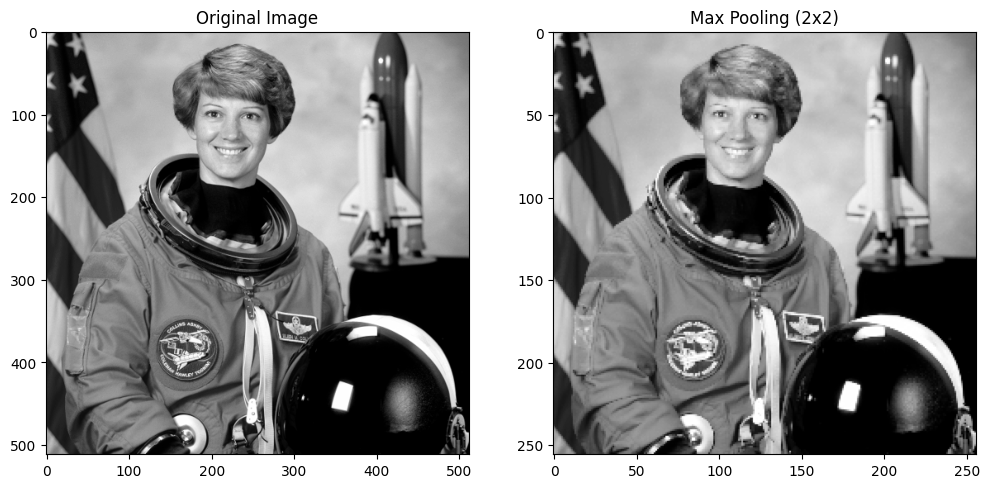

In [10]:
import torch
import torch.nn.functional as F

# Convert image to torch tensor
img_tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0).float()

# Apply 2x2 max pooling
max_pool_2x2 = F.max_pool2d(img_tensor, kernel_size=2, stride=2)

# Visualize the original and pooled images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(max_pool_2x2.squeeze().numpy(), cmap='gray')
axes[1].set_title("Max Pooling (2x2)")
plt.show()


### Upsampling with Transposed Convolution

In this step, we explore **upsampling**, a technique used to increase the size of an image by reversing the downsampling process. Specifically, we use **transposed convolution** to double the resolution of the image.

#### What is Transposed Convolution (Upsampling)?
Transposed convolution (also called **deconvolution**) is a process that expands an image by adding extra pixels, essentially reversing the effect of convolution or max pooling. This helps in situations where you need to bring the image back to a higher resolution, such as in image generation or segmentation tasks.

#### Why Use Transposed Convolution?
1. **Restoring Resolution**: After downsampling (like max pooling), we often need to increase the resolution to get an image closer to its original size.
2. **Maintaining Key Features**: Unlike simple resizing, transposed convolution is more intelligent in restoring features, as it considers learned patterns from the data.

In the code below, we apply **transposed convolution** to the previously pooled image, doubling its resolution.


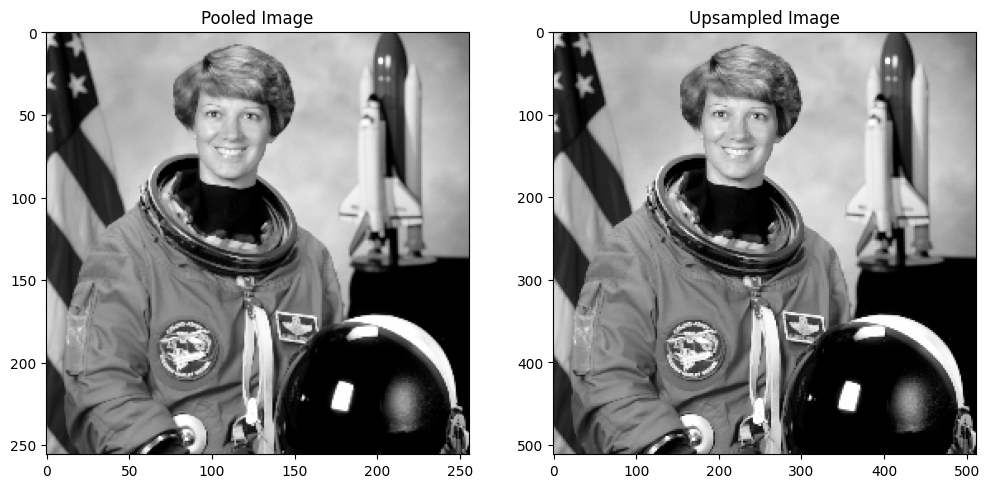

In [ ]:
# Perform upsampling (transposed convolution) to double the resolution
upsampled = F.conv_transpose2d(max_pool_2x2, torch.ones((1, 1, 2, 2)), stride=2)

# Visualize upsampled image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(max_pool_2x2.squeeze().numpy(), cmap='gray')
axes[0].set_title("Pooled Image")
axes[1].imshow(upsampled.squeeze().numpy(), cmap='gray')
axes[1].set_title("Upsampled Image")
plt.show()


### Visualizing Convolutional Kernels

In this step, we will visualize various commonly used **convolutional kernels** (or filters) as heatmaps. Each kernel serves a specific purpose in image processing, such as edge detection, blurring, sharpening, etc.

#### What are Convolutional Kernels?
A **convolutional kernel** is a small matrix used to modify an image by highlighting specific features, such as edges or corners, or by applying effects like blurring. These kernels are applied to the image using convolution to extract relevant information.

#### Kernels Used:
- **Sobel X & Y**: Detect horizontal and vertical edges in an image.
- **Prewitt X & Y**: Another set of edge detection filters.
- **Laplacian**: Detects edges by measuring the second derivative of the image.
- **Box Blur**: Averages pixel values to create a blurring effect.
- **Gaussian Blur**: Applies a smoother blur by weighting nearby pixels.
- **Sharpen**: Emphasizes edges to make the image look crisper.
- **Emboss**: Creates a 3D effect by highlighting edges.
- **Identity**: Leaves the image unchanged.

#### Also commonly used (not shown here):
- **Scharr**: Improved gradient operator vs. Sobel (better rotational symmetry, stronger response).
- **Roberts**: 2×2 diagonal edge detector (simple and fast).
- **LoG / DoG**: Laplacian of Gaussian and Difference of Gaussians for blob/edge detection and scale space.
- **Gabor**: Oriented, band‑pass filters for texture and frequency‑specific features.
- **Motion Blur (PSF)**: Linear kernels that simulate camera/subject motion.
- **Unsharp Mask / High‑boost**: Sharpening by subtracting a Gaussian blur from the original.

In the code below, we visualize each kernel using a **heatmap**, where the colors represent the values in the kernel matrix. This helps in understanding the structure of each filter.


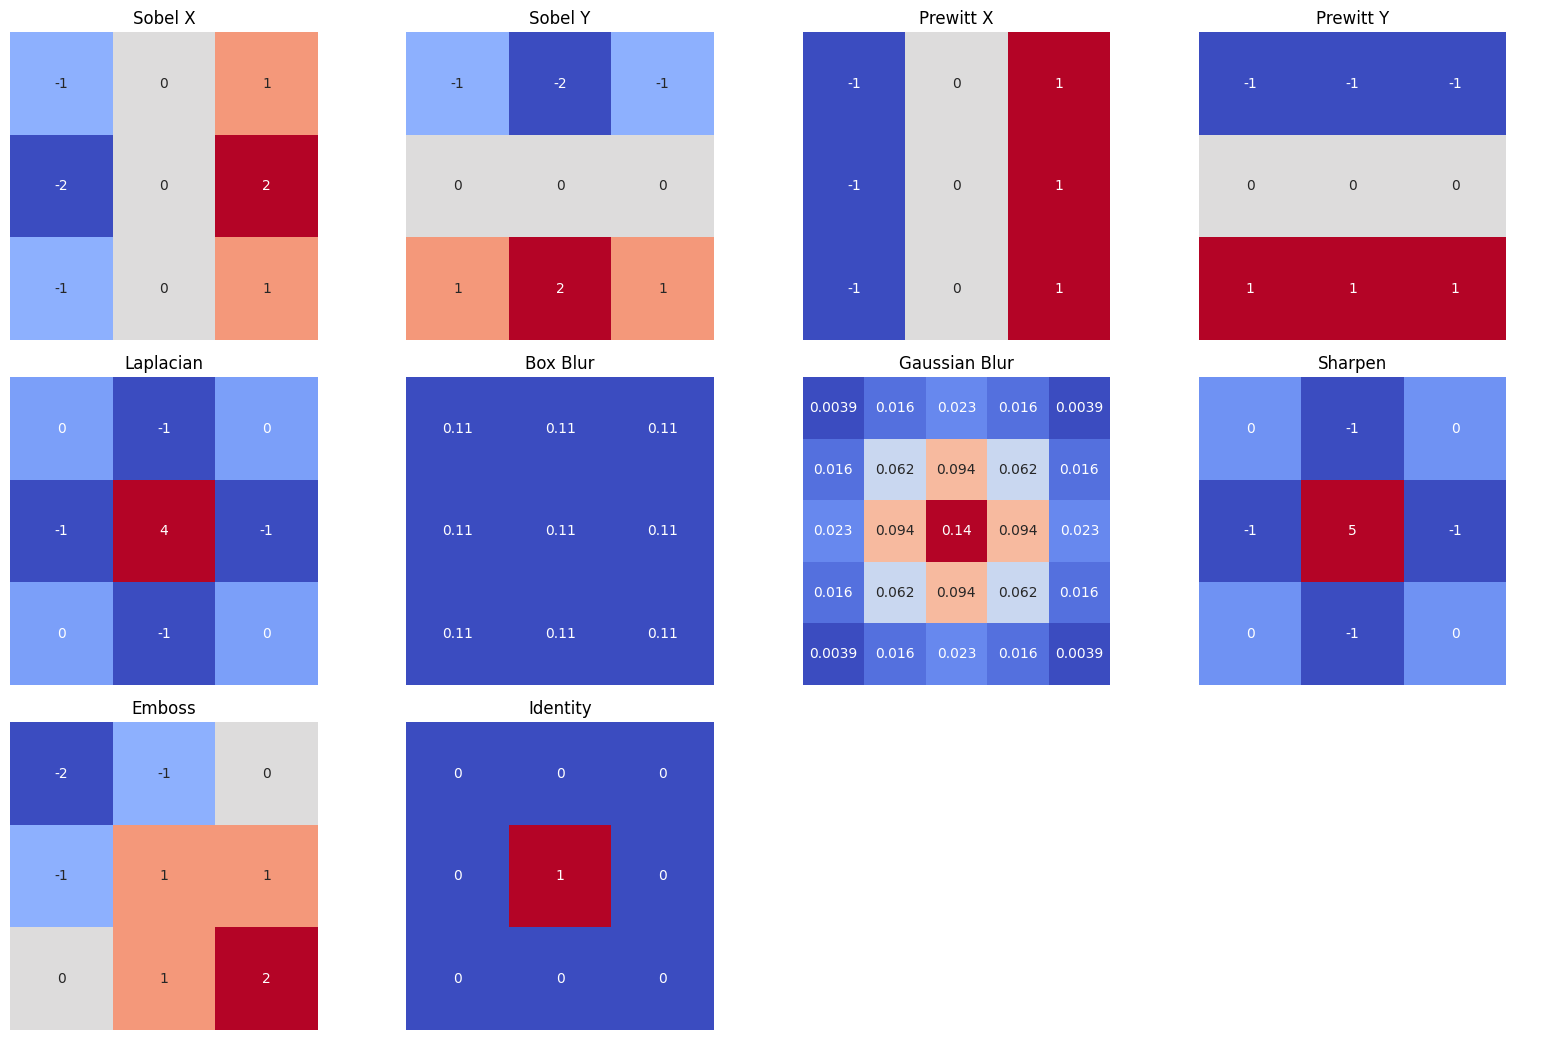

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Define all the kernels
kernels = {
    "Sobel X": np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),

    "Sobel Y": np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]]),

    "Prewitt X": np.array([[-1, 0, 1],
                           [-1, 0, 1],
                           [-1, 0, 1]]),

    "Prewitt Y": np.array([[-1, -1, -1],
                           [ 0,  0,  0],
                           [ 1,  1,  1]]),

    "Laplacian": np.array([[ 0, -1,  0],
                           [-1,  4, -1],
                           [ 0, -1,  0]]),

    "Box Blur": np.ones((3, 3)) / 9,

    "Gaussian Blur": np.array([[ 1,  4,  6,  4,  1],
                               [ 4, 16, 24, 16,  4],
                               [ 6, 24, 36, 24,  6],
                               [ 4, 16, 24, 16,  4],
                               [ 1,  4,  6,  4,  1]]) / 256,

    "Sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),

    "Emboss": np.array([[-2, -1,  0],
                        [-1,  1,  1],
                         [ 0,  1,  2]]),

    "Identity": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]])
}

# Dynamic grid sized to the number of kernels
n = len(kernels)
cols = 4
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
axes = np.atleast_1d(axes).ravel()

# Plot each kernel as a heatmap
for idx, (kernel_name, kernel_matrix) in enumerate(kernels.items()):
    sns.heatmap(kernel_matrix, annot=True, cmap='coolwarm', cbar=False, square=True, ax=axes[idx])
    axes[idx].set_title(kernel_name)
    axes[idx].axis('off')

# Hide any unused axes
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


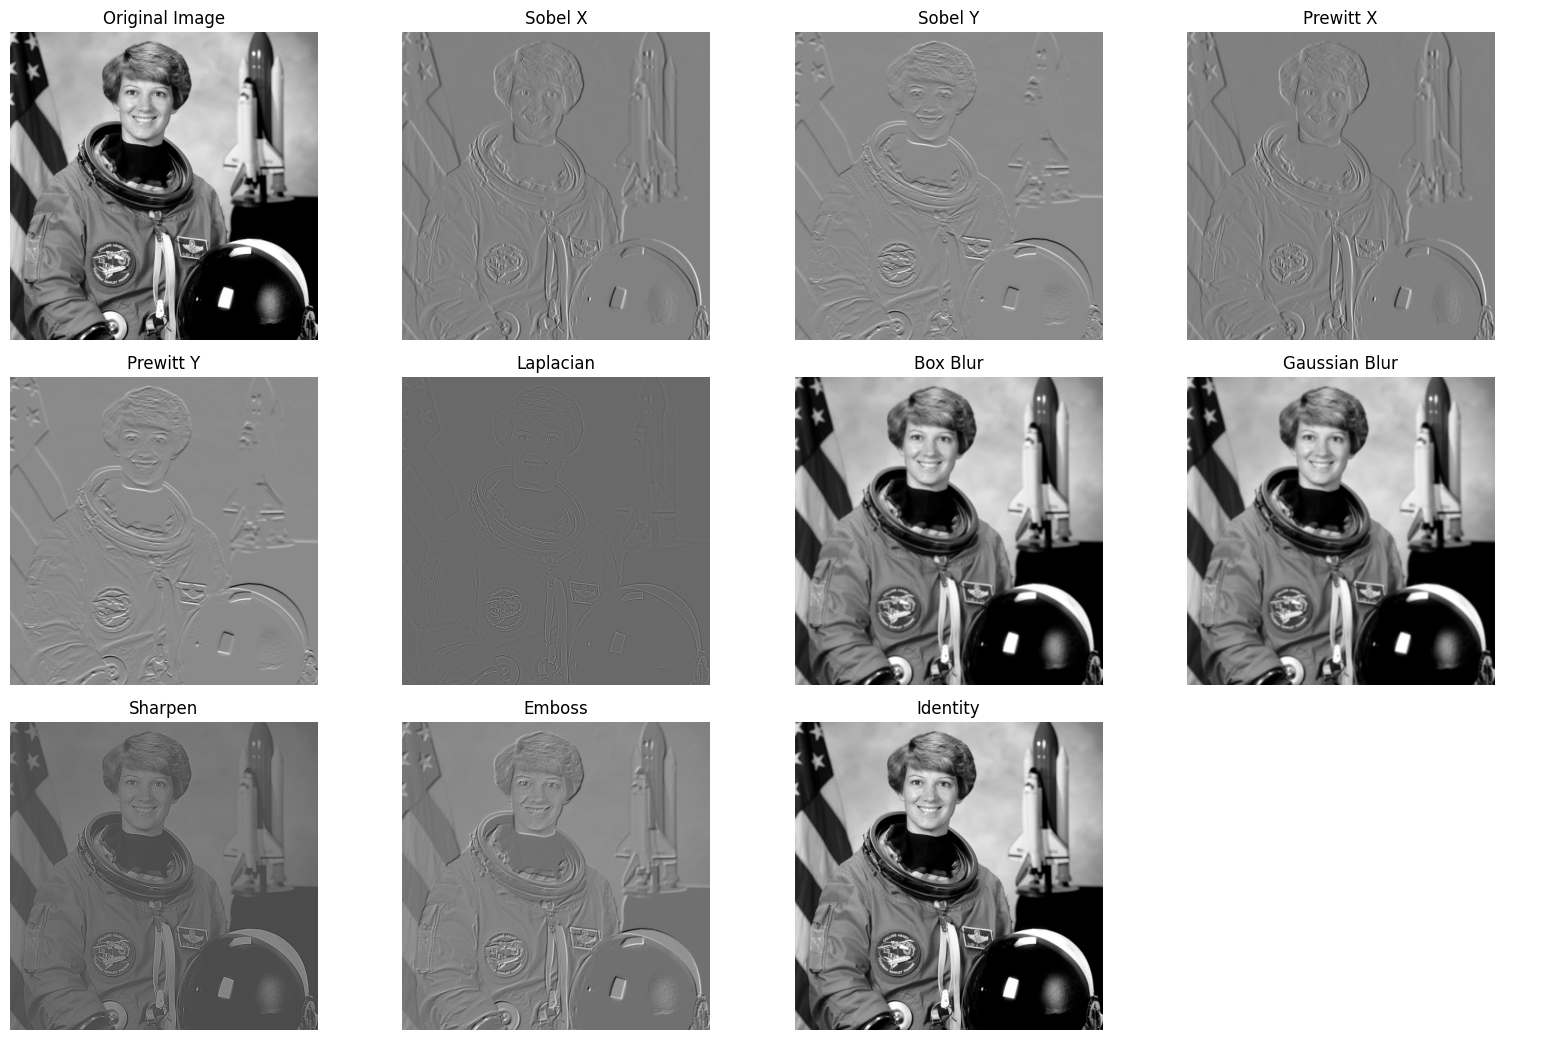

In [13]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import math

# Define all the kernels (aligned with the overview)
kernels = {
    "Sobel X": np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),

    "Sobel Y": np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]]),

    "Prewitt X": np.array([[-1, 0, 1],
                           [-1, 0, 1],
                           [-1, 0, 1]]),

    "Prewitt Y": np.array([[-1, -1, -1],
                           [ 0,  0,  0],
                           [ 1,  1,  1]]),

    "Laplacian": np.array([[ 0, -1,  0],
                           [-1,  4, -1],
                           [ 0, -1,  0]]),

    "Box Blur": np.ones((3, 3)) / 9,

    # Use the same 5x5 Gaussian as in the heatmap cell
    "Gaussian Blur": np.array([[ 1,  4,  6,  4,  1],
                               [ 4, 16, 24, 16,  4],
                               [ 6, 24, 36, 24,  6],
                               [ 4, 16, 24, 16,  4],
                               [ 1,  4,  6,  4,  1]]) / 256,

    "Sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),

    "Emboss": np.array([[-2, -1,  0],
                        [-1,  1,  1],
                         [ 0,  1,  2]]),

    "Identity": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]])
}

# Dynamic grid sized to original + number of kernels
n_k = len(kernels)
cols = 4
rows = math.ceil((1 + n_k) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
axes = np.atleast_1d(axes).ravel()

# Plot the original image
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Apply each kernel to the image and plot the result
for idx, (kernel_name, kernel_matrix) in enumerate(kernels.items(), start=1):
    convolved_image = convolve2d(img_array, kernel_matrix, mode='same', boundary='symm')
    axes[idx].imshow(convolved_image, cmap='gray')
    axes[idx].set_title(kernel_name)
    axes[idx].axis('off')

# Hide any unused axes
for j in range(1 + n_k, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Gaussian Kernels: What, Why, and Where

A **Gaussian kernel** is a discrete sample of a Gaussian (normal) distribution used as a smoothing filter. Nearby pixels get higher weights and distant pixels get lower weights according to a bell‑shaped curve.

- **What it does**:
  - Produces a weighted average of neighboring pixels, suppressing high‑frequency noise while preserving overall structure.
  - The kernel is separable into horizontal and vertical 1D Gaussians, enabling efficient implementation.

- **Why it’s used**:
  - **Denoising / smoothing**: Reduce sensor noise and JPEG artifacts before further processing.
  - **Preprocessing for edge detection**: Blur slightly to stabilize gradient operators (e.g., Canny uses Gaussian smoothing first).
  - **Scale space analysis**: Varying the Gaussian’s standard deviation (σ) reveals features at different spatial scales.
  - **Anti‑aliasing**: Smooth before downsampling to avoid aliasing artifacts.

- **Where you’ll see it**:
  - Classical vision pipelines (OpenCV, SciPy), computational photography, medical imaging, remote sensing, graphics.
  - As building blocks in algorithms like **LoG** (Laplacian of Gaussian), **DoG** (Difference of Gaussians), and as the blur in **unsharp masking**.

- **Parameters**:
  - **Kernel size**: Typically chosen to cover ~3σ on each side; common sizes: 3×3, 5×5, 7×7, …
  - **σ (sigma)**: Controls the amount of blur. Larger σ = stronger smoothing.

Below we already visualize a 5×5 Gaussian kernel. In later cells, you’ll also see a larger Gaussian and how changing σ affects the blur strength.


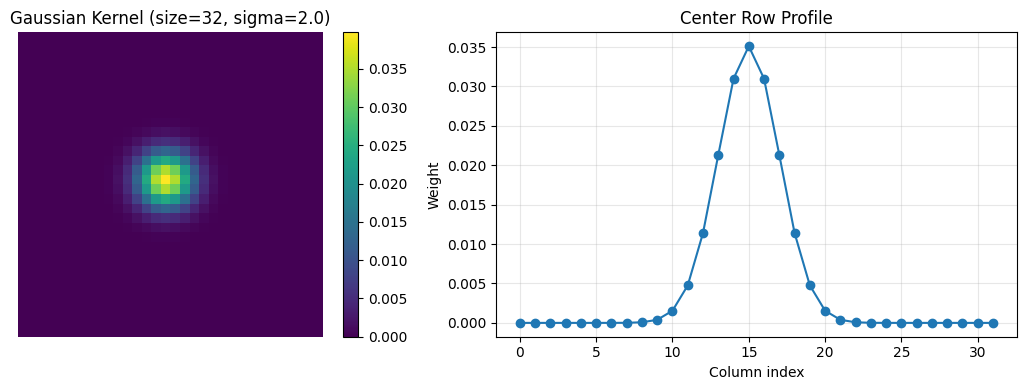

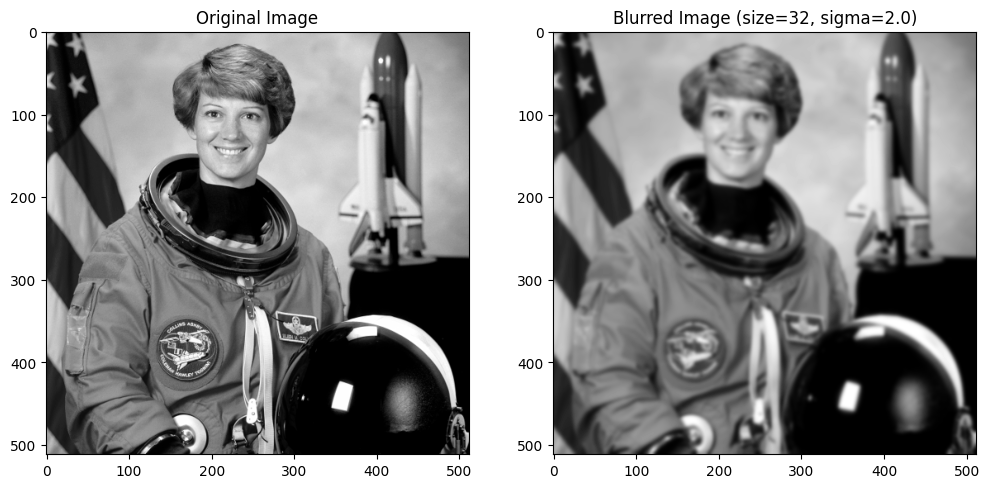

In [18]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from PIL import Image

# Function to create a 2D Gaussian kernel
def gaussian_kernel(size, sigma=1):
    """
    Create a 2D Gaussian kernel.

    Parameters:
    size (int): The size of the kernel (size x size).
    sigma (float): Standard deviation of the Gaussian distribution.

    Returns:
    np.ndarray: Gaussian kernel of shape (size, size).
    """
    # Create a grid of (x, y) coordinates
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)

    # Calculate the 2D Gaussian kernel using the formula
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))

    # Normalize the kernel so that the sum of all elements is 1
    kernel = kernel / np.sum(kernel)

    return kernel

# Create a Gaussian kernel with a variable size and sigma
size = 32  # You can change the size
sigma = 2.0  # You can change sigma
gaussian_k = gaussian_kernel(size, sigma)  # Rename the variable to avoid conflict

# --- Visualize the Gaussian kernel: heatmap + center-row profile ---
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
im = axs[0].imshow(gaussian_k, cmap='viridis')
axs[0].set_title(f"Gaussian Kernel (size={size}, sigma={sigma})")
axs[0].axis('off')
plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
center_row = gaussian_k[size // 2, :]
axs[1].plot(center_row, marker='o')
axs[1].set_title("Center Row Profile")
axs[1].set_xlabel("Column index")
axs[1].set_ylabel("Weight")
axs[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Apply the 2D convolution with Gaussian blur
blurred_image = convolve2d(img_array, gaussian_k, mode='same', boundary='symm')

# Plot the original and blurred image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title(f"Blurred Image (size={size}, sigma={sigma})")
plt.show()


### Visualizing Kernels and Feature Maps in a CNN

In this example, we explore how Convolutional Neural Networks (CNNs) process an image. We'll create a simple **binary spiral image**, pass it through two convolutional layers, and visualize both the **kernels** (the filters) and the resulting **feature maps** at each stage. This provides a clear, step-by-step view of how CNNs learn to detect and represent features.

#### Step-by-Step Process:

1.  **Creating a Binary Spiral Image**:
    *   We generate a 64x64 binary image of a spiral. This simple, high-contrast shape is an ideal input for observing how convolutions extract basic structural features. Initially, the image has only one channel and its pixels are either 0 (black) or 1 (white).

2.  **The Convolutional Layers**:
    *   We use two `Conv2d` layers to process the image. The key idea is that each layer learns to identify patterns, passing its findings to the next layer to detect progressively more complex features.
    *   **What are Kernels?** Kernels (or filters) are small matrices of weights that the network learns. Before training, these are filled with small, random numbers. We visualize these initial random kernels to see their starting state. During training, these kernels would evolve into meaningful pattern detectors.
    *   **What are Channels?** The `out_channels` parameter defines the number of kernels the layer will use. Think of each channel as a unique feature detector. If `out_channels=4`, the layer learns 4 different kernels and produces 4 corresponding feature maps. This does **not** determine the number of shades; it determines the number of *maps* we get as output.
        *   **Conv1**: Takes the 1-channel input and applies 4 different kernels, producing 4 distinct feature maps.
        *   **Conv2**: Takes the 4 feature maps from Conv1 as its input. It applies a new set of kernels to create 8 even more abstract feature maps.

3.  **Visualization and Interpretation**:
    *   **Kernels**: We plot the weights of the kernels for each layer. These visualizations show the raw patterns the layer is looking for. Initially random, these would become structured (e.g., edge detectors) after training.
    *   **Feature Maps & Palettes**: After each convolution, we visualize the output.
        *   A **Feature Map** is the output from a single kernel, highlighting where its specific pattern was detected in the input.
        *   The **Palette** shown below each map is a crucial visual cue. It displays all the unique pixel values (shades of gray) present in that specific map. This visualizes the transformation from a simple binary input (with a palette of only two shades) to a much richer, multi-tonal output where the different shades represent the strength of the feature detection.
    *   **Resolution**: Notice the label "Resolution: 64x64" on each output. Because we use `padding=1` with a 3x3 kernel and `stride=1`, the spatial dimensions of the feature maps are preserved. This is a common technique to maintain resolution while deepening feature extraction.

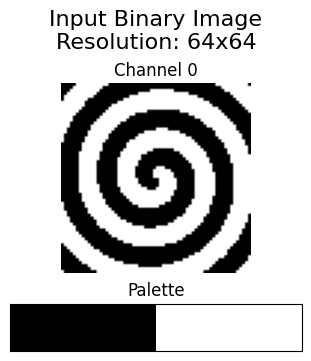

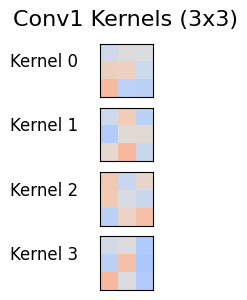

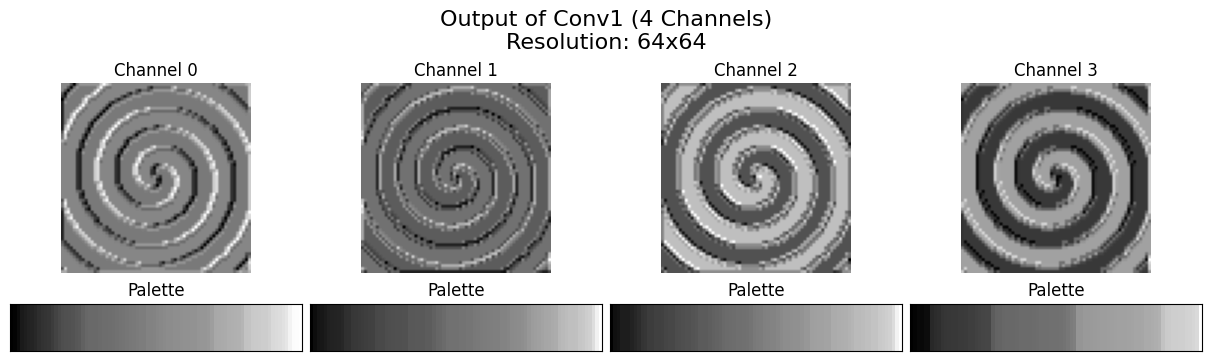

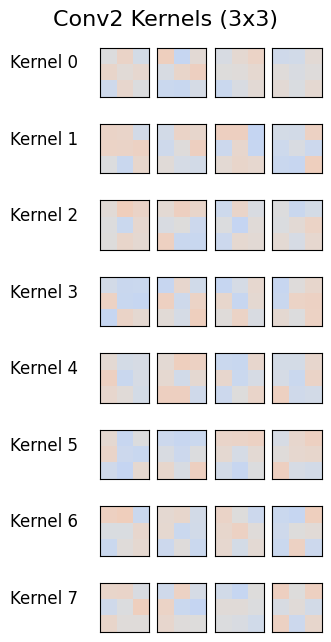

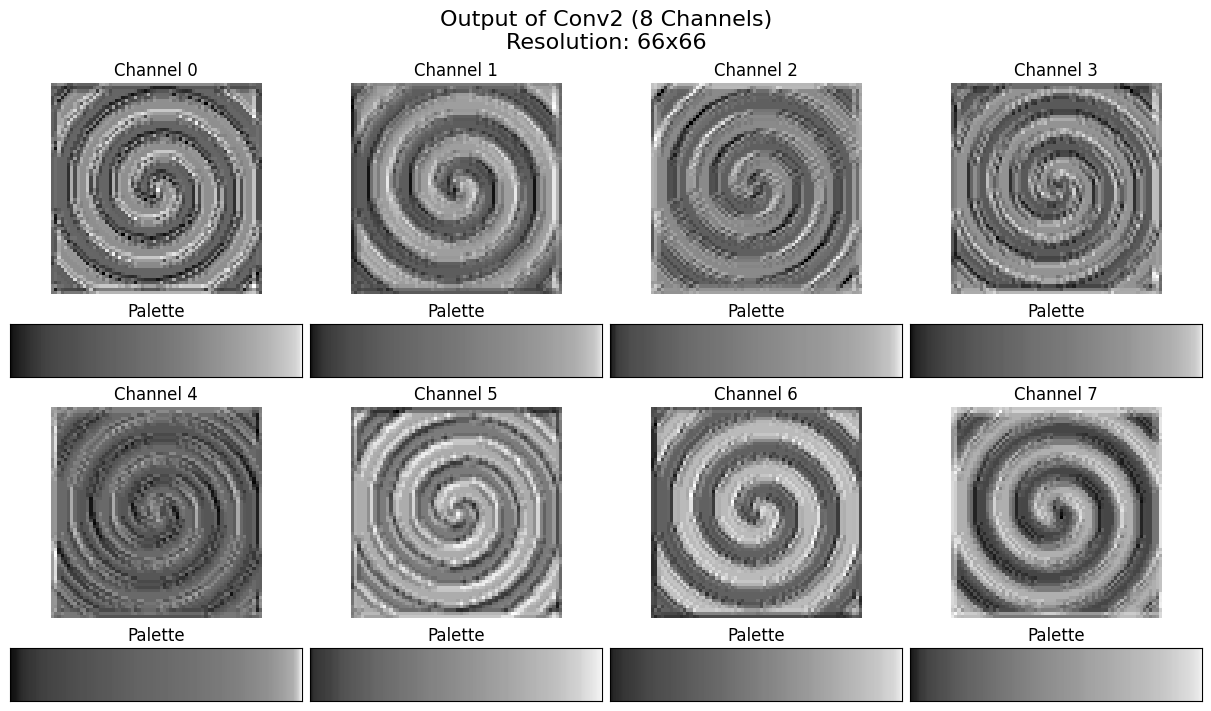

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import math

def visualize_kernels(tensor, title=""):
    """
    Visualizes convolutional kernels with a consistent, explicit pixel size for each kernel subplot.

    Args:
        tensor (torch.Tensor): The weights tensor of the convolutional layer.
        title (str, optional): The title for the visualization. Defaults to "".
    """
    # --- ROBUST SIZING LOGIC ---
    # Define a target size for each kernel in pixels. This is the key to consistency.
    kernel_display_size_px = 80
    # Define the DPI (dots per inch) for the figure.
    dpi = 100

    out_channels, in_channels, k_height, k_width = tensor.shape
    
    # Calculate the total figure size in pixels based on the number of kernels.
    fig_width_px = in_channels * kernel_display_size_px
    fig_height_px = out_channels * kernel_display_size_px
    
    # Convert pixel dimensions to inches for Matplotlib's figsize.
    figsize = (fig_width_px / dpi, fig_height_px / dpi)

    # Create the figure with the calculated size and DPI.
    fig, axes = plt.subplots(out_channels, in_channels, figsize=figsize, dpi=dpi, squeeze=False, constrained_layout=True)

    for out_c in range(out_channels):
        for in_c in range(in_channels):
            kernel = tensor[out_c, in_c].detach().numpy()
            ax = axes[out_c, in_c]
            ax.imshow(kernel, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
            ax.set_xticks([])
            ax.set_yticks([])
            if in_c == 0:
                ax.set_ylabel(f'Kernel {out_c}', rotation=0, size='large', labelpad=40) # Increased labelpad

    plt.suptitle(title, fontsize=16)
    # Adjust layout to prevent title/label overlap.
    plt.show()


def visualize_feature_maps_with_palettes(tensor, title="", max_maps=8):
    """
    Visualizes feature maps in a grid for consistent sizing.

    Args:
        tensor (torch.Tensor): The input tensor with feature maps.
        title (str, optional): The title for the visualization. Defaults to "".
        max_maps (int, optional): The maximum number of feature maps to display. Defaults to 8.
    """
    subplot_width = 3
    subplot_height_total = 3.5

    n_maps = min(tensor.shape[1], max_maps)
    if n_maps == 0: return
        
    height, width = tensor.shape[2], tensor.shape[3]
    tensor_normalized = (tensor - tensor.min()) / (tensor.max() - tensor.min())

    cols = min(n_maps, 4)
    rows = math.ceil(n_maps / cols)
    
    fig, axes = plt.subplots(rows * 2, cols, 
                             figsize=(cols * subplot_width, rows * subplot_height_total), 
                             gridspec_kw={'height_ratios': [4, 1] * rows},
                             squeeze=False,
                             constrained_layout=True)

    for i in range(n_maps):
        row_idx, col_idx = i // cols, i % cols
        map_ax, palette_ax = axes[row_idx * 2, col_idx], axes[row_idx * 2 + 1, col_idx]

        map_ax.imshow(tensor_normalized[0, i].detach().numpy(), cmap='gray')
        map_ax.set_title(f"Channel {i}")
        map_ax.axis('off')

        unique_values = torch.unique(tensor[0, i])
        palette = unique_values.unsqueeze(0).detach().numpy()
        palette_ax.imshow(palette, cmap='gray', aspect='auto')
        palette_ax.set_title("Palette")
        palette_ax.get_yaxis().set_visible(False)
        palette_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    for i in range(n_maps, rows * cols):
        row_idx, col_idx = i // cols, i % cols
        axes[row_idx * 2, col_idx].axis('off')
        axes[row_idx * 2 + 1, col_idx].axis('off')

    full_title = f"{title}\nResolution: {height}x{width}"
    plt.suptitle(full_title, fontsize=16)
    plt.show()

# Step 1: Create a binary image with a spiral shape
def create_spiral_image(size=64):
    x = np.linspace(-3, 3, size)
    y = np.linspace(-3, 3, size)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(5 * (np.sqrt(X**2 + Y**2)) - np.arctan2(Y, X))
    spiral = (Z > 0).astype(float)
    return spiral

# Create a spiral image
spiral_image = create_spiral_image(size=64)
input_tensor = torch.tensor(spiral_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Visualize the binary input image
visualize_feature_maps_with_palettes(input_tensor, title="Input Binary Image")

# --- First Convolutional Layer ---
conv1_out_channels = 4
conv1 = nn.Conv2d(in_channels=1, out_channels=conv1_out_channels, kernel_size=3, stride=1, padding=1)
visualize_kernels(conv1.weight, title="Conv1 Kernels (3x3)")
output_tensor1 = conv1(input_tensor)
visualize_feature_maps_with_palettes(output_tensor1, title=f"Output of Conv1 ({conv1_out_channels} Channels)")

# --- Second Convolutional Layer ---
conv2_out_channels = 8
conv2 = nn.Conv2d(in_channels=conv1_out_channels, out_channels=conv2_out_channels, kernel_size=3, stride=1, padding=1)
visualize_kernels(conv2.weight, title="Conv2 Kernels (3x3)")
output_tensor2 = conv2(output_tensor1)
visualize_feature_maps_with_palettes(output_tensor2, title=f"Output of Conv2 ({conv2_out_channels} Channels)")

Experiments with stride 2 => halving the image

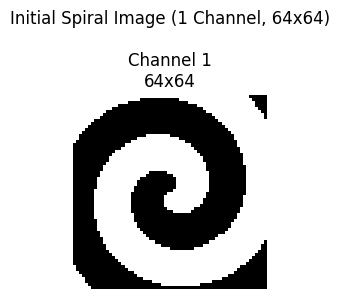

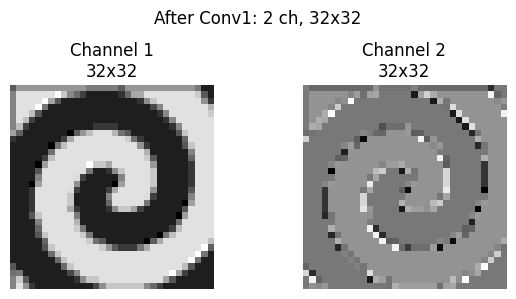

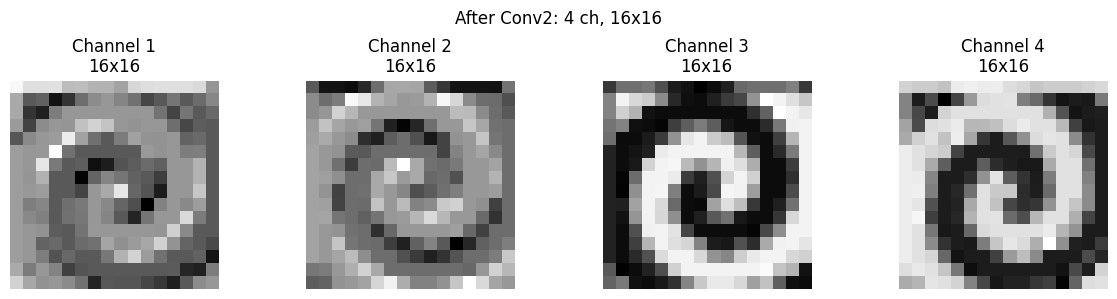

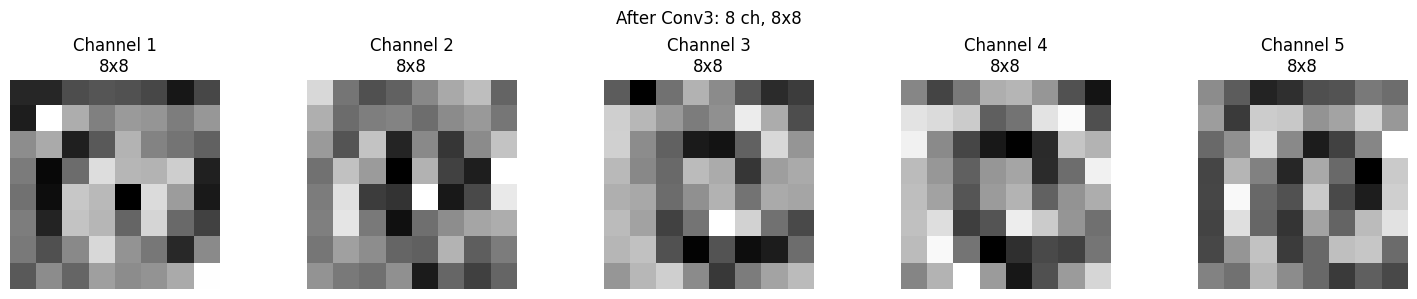

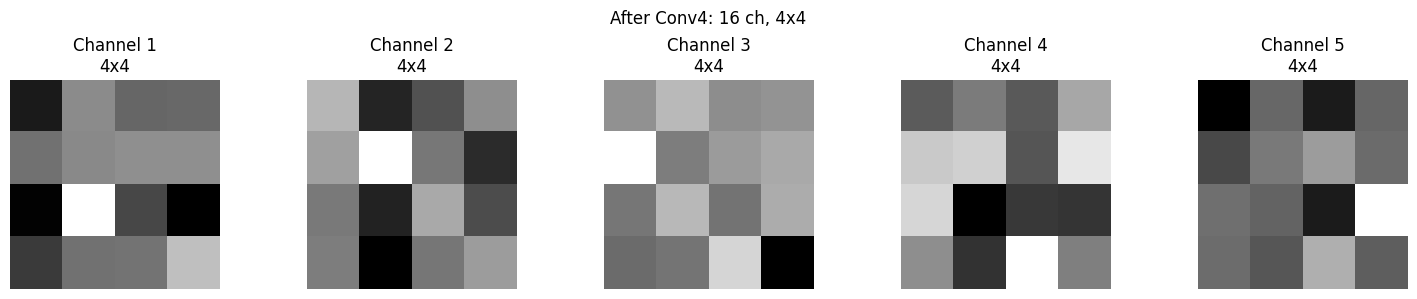

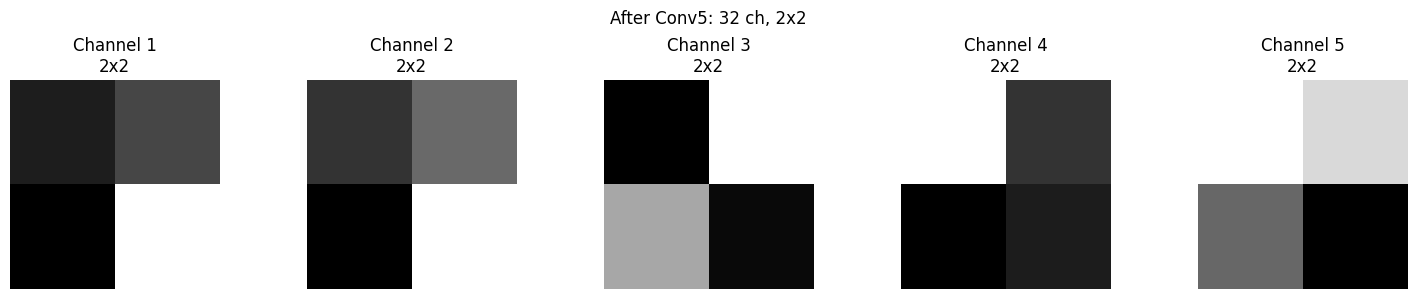

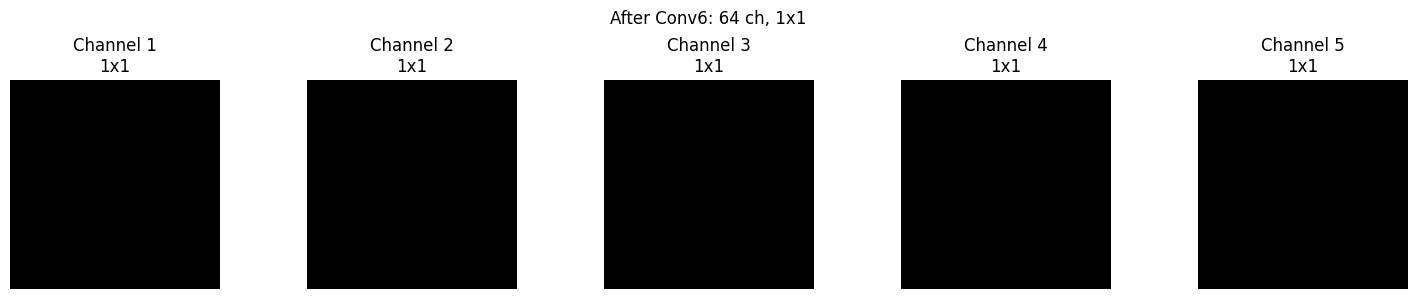

Final shape: (1, 64, 1, 1)
Vector shape: (1, 64)


In [41]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import math

# Function to visualize feature maps (unchanged)
def visualize_feature_maps(tensor, title=""):
    n_maps = tensor.shape[1]
    n_maps_to_show = min(n_maps, 5)
    spatial_h, spatial_w = tensor.shape[2], tensor.shape[3]

    fig, axes = plt.subplots(1, n_maps_to_show, figsize=(3 * n_maps_to_show, 3))
    if n_maps_to_show == 1:
        axes = [axes]

    for i in range(n_maps_to_show):
        feature_map = tensor[0, i].detach().cpu().numpy()
        axes[i].imshow(feature_map, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Channel {i+1}\n{spatial_h}x{spatial_w}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def create_spiral_image(size=64):
    x = np.linspace(-2, 2, size)
    y = np.linspace(-2, 2, size)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(4 * np.sqrt(X**2 + Y**2) + np.arctan2(Y, X))
    return (Z > 0).astype(float)

# Input
size = 64
spiral_image = create_spiral_image(size=size)
input_tensor = torch.tensor(spiral_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

visualize_feature_maps(input_tensor, title=f"Initial Spiral Image (1 Channel, {size}x{size})")

# Build conv stack to reach 1x1 spatial and 64 channels
target_channels = 64
n_down = int(math.log2(size))  # 64 -> 1 needs 6 downsamples
assert 2**n_down == size, "Input size must be power of 2 for pure stride-2 halving."

conv_layers = []
current_channels = 1
for i in range(n_down):  # <-- 6 layers when size=64
    out_channels = min(current_channels * 2, target_channels)
    conv_layers.append(nn.Conv2d(current_channels, out_channels, kernel_size=3, stride=2, padding=1))
    current_channels = out_channels

current_tensor = input_tensor
for idx, conv in enumerate(conv_layers):
    current_tensor = conv(current_tensor)
    title = f"After Conv{idx+1}: {current_tensor.shape[1]} ch, {current_tensor.shape[2]}x{current_tensor.shape[3]}"
    visualize_feature_maps(current_tensor, title=title)

print("Final shape:", tuple(current_tensor.shape))  # should be (1, 64, 1, 1)

# If you want a 64-dim vector:
vec = current_tensor.squeeze(-1).squeeze(-1)  # shape (1, 64)
print("Vector shape:", tuple(vec.shape))


kernel stride padding experiments

--- Example 1: Resolution Preservation ---


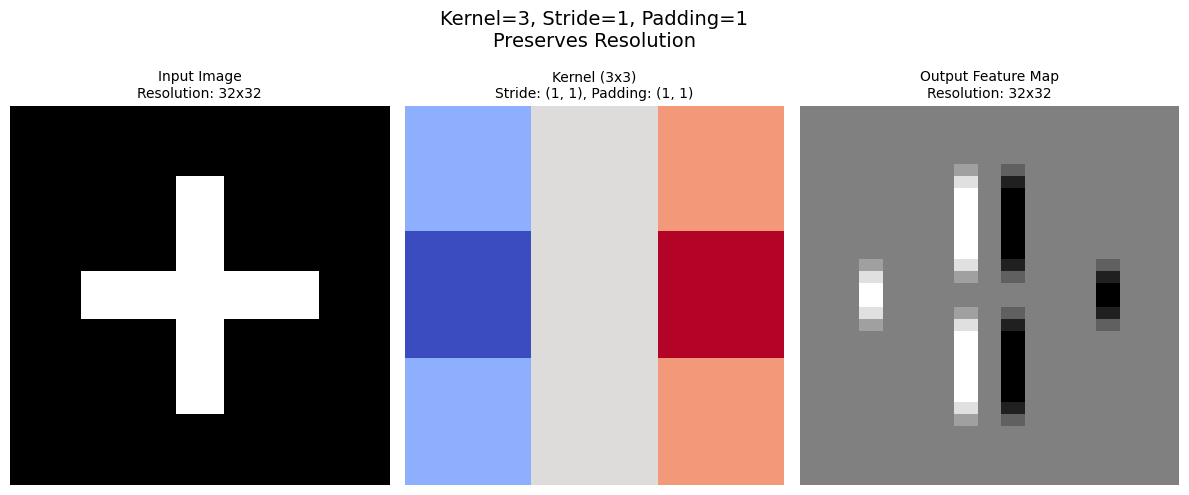

Calculation: floor((32 - 3 + 2*1) / 1) + 1 = 32. The output size is the same as the input.

--- Example 2: Downsampling with Stride ---


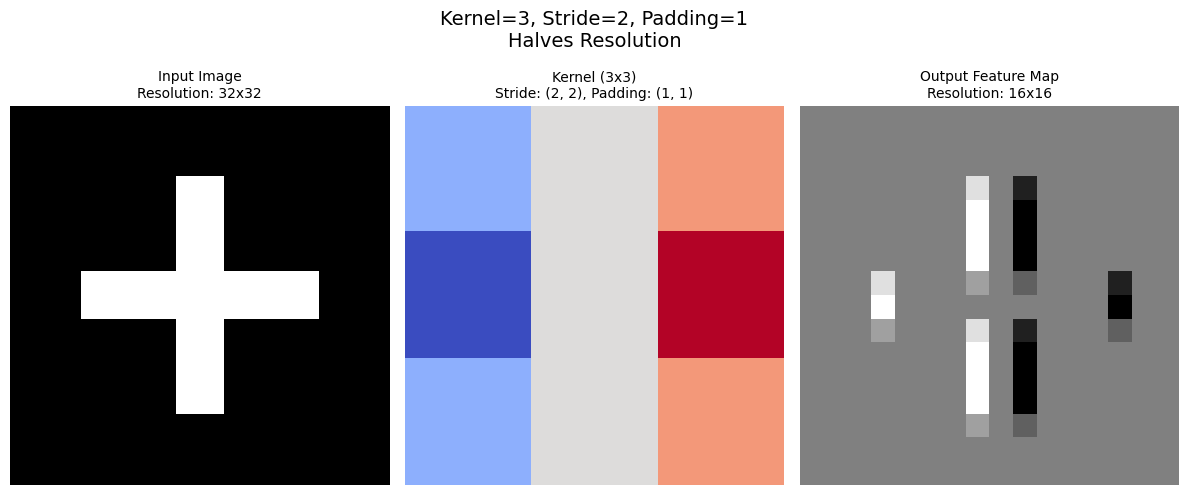

Calculation: floor((32 - 3 + 2*1) / 2) + 1 = 16. The output is half the size of the input.

--- Example 3: No Padding ('Valid' Convolution) ---


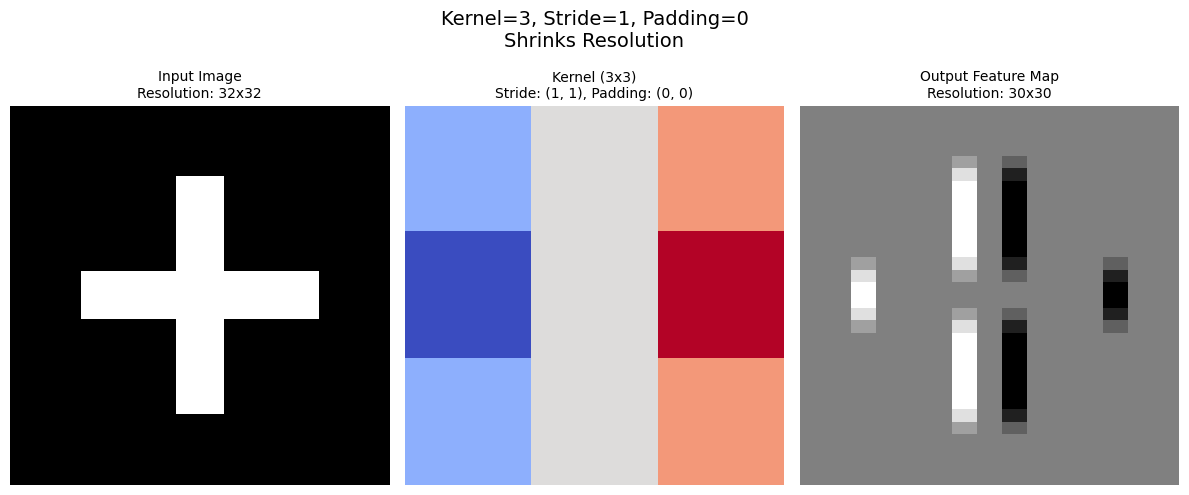

Calculation: floor((32 - 3 + 2*0) / 1) + 1 = 30. The image shrinks by 2 pixels (k-1).

--- Example 4: Large Kernel and Stride ---


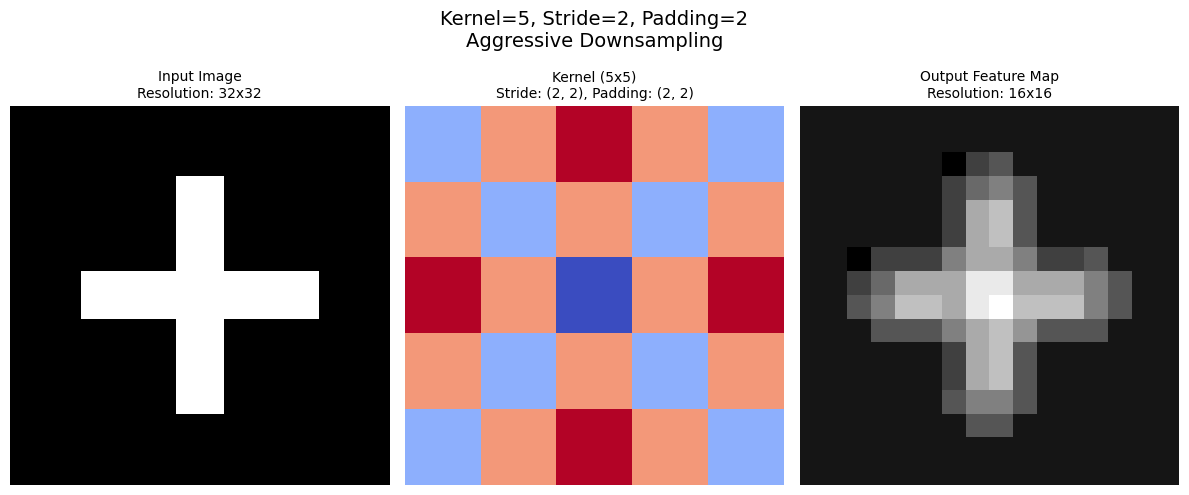

Calculation: floor((32 - 5 + 2*2) / 2) + 1 = 16. The large kernel and stride combine to reduce size.


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# --- Helper Function for Visualization (Refined for Clarity) ---

def show_convolution_effect(input_tensor, conv_layer, title=""):
    """
    Visualizes the input, kernel, and output of a single convolution operation
    with improved layout and font sizes to prevent clutter.
    """
    output_tensor = conv_layer(input_tensor)
    
    kernel = conv_layer.weight.detach()
    stride = conv_layer.stride
    padding = conv_layer.padding
    kernel_size = conv_layer.kernel_size
    
    in_res = input_tensor.shape[2]
    out_res = output_tensor.shape[2]

    # --- AESTHETIC IMPROVEMENT ---
    # Increased figure height for more vertical space.
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    
    # Input Image
    axes[0].imshow(input_tensor[0, 0].numpy(), cmap='gray')
    # Reduced font size for subplot titles.
    axes[0].set_title(f"Input Image\nResolution: {in_res}x{in_res}", fontsize=10)
    axes[0].axis('off')

    # Kernel
    axes[1].imshow(kernel[0, 0].numpy(), cmap='coolwarm', vmin=-2, vmax=2, interpolation='nearest')
    axes[1].set_title(f"Kernel ({kernel_size[0]}x{kernel_size[1]})\nStride: {stride}, Padding: {padding}", fontsize=10)
    axes[1].axis('off')

    # Output Feature Map
    axes[2].imshow(output_tensor[0, 0].detach().numpy(), cmap='gray')
    axes[2].set_title(f"Output Feature Map\nResolution: {out_res}x{out_res}", fontsize=10)
    axes[2].axis('off')
    
    # --- AESTHETIC IMPROVEMENT ---
    # Reduced font size for the main title.
    plt.suptitle(title, fontsize=14)
    
    # Use tight_layout with a 'rect' argument to prevent the main title from overlapping
    # with the subplot titles. This reserves space at the top of the figure.
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    
    plt.show()

# --- Create a Simple and Clear Input Image ---
def create_cross_image(size=32):
    image = np.zeros((size, size))
    center = size // 2
    image[center-10:center+10, center-2:center+2] = 1
    image[center-2:center+2, center-10:center+10] = 1
    return torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

input_image = create_cross_image(size=32)

# ==============================================================================
# --- Example 1: Resolution Preservation ("Same" Convolution) ---
# ==============================================================================
print("--- Example 1: Resolution Preservation ---")
k, s, p = 3, 1, 1
conv1 = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p, bias=False)
vertical_edge_kernel = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).unsqueeze(0).unsqueeze(0)
conv1.weight.data = vertical_edge_kernel
show_convolution_effect(input_image, conv1, title=f"Kernel={k}, Stride={s}, Padding={p}\nPreserves Resolution")
print("Calculation: floor((32 - 3 + 2*1) / 1) + 1 = 32. The output size is the same as the input.")


# ==============================================================================
# --- Example 2: Downsampling with Stride ---
# ==============================================================================
print("\n--- Example 2: Downsampling with Stride ---")
k, s, p = 3, 2, 1
conv2 = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p, bias=False)
conv2.weight.data = vertical_edge_kernel
show_convolution_effect(input_image, conv2, title=f"Kernel={k}, Stride={s}, Padding={p}\nHalves Resolution")
print("Calculation: floor((32 - 3 + 2*1) / 2) + 1 = 16. The output is half the size of the input.")


# ==============================================================================
# --- Example 3: No Padding ("Valid" Convolution) ---
# ==============================================================================
print("\n--- Example 3: No Padding ('Valid' Convolution) ---")
k, s, p = 3, 1, 0
conv3 = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p, bias=False)
conv3.weight.data = vertical_edge_kernel
show_convolution_effect(input_image, conv3, title=f"Kernel={k}, Stride={s}, Padding={p}\nShrinks Resolution")
print("Calculation: floor((32 - 3 + 2*0) / 1) + 1 = 30. The image shrinks by 2 pixels (k-1).")


# ==============================================================================
# --- Example 4: Large Kernel and Stride ---
# ==============================================================================
print("\n--- Example 4: Large Kernel and Stride ---")
k, s, p = 5, 2, 2
conv4 = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p, bias=False)
cross_kernel = torch.tensor([
    [-1., 1., 2., 1., -1.],
    [ 1., -1., 1.,-1.,  1.],
    [ 2., 1., -2., 1.,  2.],
    [ 1., -1., 1.,-1.,  1.],
    [-1., 1., 2., 1., -1.]
]).unsqueeze(0).unsqueeze(0)
conv4.weight.data = cross_kernel
show_convolution_effect(input_image, conv4, title=f"Kernel={k}, Stride={s}, Padding={p}\nAggressive Downsampling")
print("Calculation: floor((32 - 5 + 2*2) / 2) + 1 = 16. The large kernel and stride combine to reduce size.")